**Overview**  
This notebook is analogous to the previous one and describes folloiwing stages:
1. Creating functions to:
    - perform search for optimal algorithm parameters, whereas splitting into the train and test folds  on the previous stage is performed on the base of chemical nature of the additive;
    - train optimal model;
    - calculate the most important metrics;
    - plot ROC-AUC curve
2. Assess the results of following algorithms:
    - Logistic regression;
    - Random Forest;
    - Gradient Boosting as implemented in XGBoost;
    - Support Vector Machines;
    - K-Nearest Neighborrs
3. Creare dataframe with the main indiators of models' performance

In [26]:
import numpy as np
import pandas as pd
import pickle
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedGroupKFold, GridSearchCV, GroupShuffleSplit, cross_val_score
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score, precision_score, roc_curve, recall_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from hyperopt import tpe, Trials, hp, fmin, STATUS_OK
from functools import partial
from sklearn.neighbors import KNeighborsClassifier

First, let's import datasets and y-target, created earlier:

In [2]:
with open('X_padel_dropped.pickle', 'rb') as input:
    X_padel_dropped = pickle.load(input)

In [3]:
with open('X_standard_dropped.pickle', 'rb') as input:
    X_standard_dropped = pickle.load(input)

In [4]:
with open('y.pickle', 'rb') as input:
    target = pickle.load(input)


In [5]:
with open('X_standard_pca.pickle', 'rb') as input:
    X_standard_pca = pickle.load(input)

In [6]:
with open('X_padel_pca.pickle', 'rb') as input:
    X_padel_pca = pickle.load(input)

In [7]:
with open('groups.pickle', 'rb') as input:
    groups = pickle.load(input)

To facilitate automatic calculation of metrics and asiggning labels, we weill create dictionaries with imported descriptors datasets (standard datasets and datasetes with reduced dimensionality) and instantiate the scores dictionary

In [15]:
descriptors_dict = {'Standard':X_standard_dropped, 'Padel':X_padel_dropped}
descriptors_dict_pca = {'Standard':X_standard_pca, 'Padel':X_padel_pca}

The function below performs multiple tasks:
1. First, it create matplotlib figure object and axes with two fields,
2. Then for each of two datasets in descriptors dictionary (standard and PCA), we:
    - Create a pipeline, made of MinMaxScaler and algorithm,
    - Split dataset into training and testing subsets such that all instances where additive is the same are assigned to the same set;
    - Then we search for optimal parameters with functions from [hyperopt package](http://hyperopt.github.io/hyperopt/), the search is based on cross-validation, assigning the sample into the training  or test fold is performed based on the chemical nature of the additive (as in the case of train_test_splitting);
    - Then we extract the best model and train it with X_train and y_train;
    - Then we claculate different metrics (Accuracy, F1-Score, ROC_AUC score) and append it to the special dictionary with results, as well as some information abour descriptors sets and name of studied algorithm
    - Finally, we plot ROC-AUC curve 

In [10]:
def get_best_model_from_trials(trials):
    valid_trial_list = [trial for trial in trials if trial['result']['status'] == STATUS_OK]
    losses = [ float(trial['result']['loss']) for trial in valid_trial_list]
    index_having_minumum_loss = np.argmin(losses)
    best_trial_obj = valid_trial_list[index_having_minumum_loss]
    return best_trial_obj['result']['Trained_model']

In [27]:
def calculate_to_score(estimator, estimator_name, param_grid, descriptors_dict = descriptors_dict, target=target, type = 'Full', groups = groups):
    fig, axes = plt.subplots(1, 2, figsize = (12,8))
    i = 0
    for key, value in descriptors_dict.items():
        #split based on grou[s
        splitter = GroupShuffleSplit(n_splits=2, random_state = 0)
        split = splitter.split(X = value, y = target, groups = groups)
        train_indices, test_indices = next(split)
        X_train, y_train, groups_train = value.iloc[train_indices], target.iloc[train_indices], groups[train_indices]
        X_test, y_test, groups_test = value.iloc[test_indices], target.iloc[test_indices], groups[test_indices]
        #New K-fold stratification
        cv = StratifiedGroupKFold()
        #objective function
        def objective(params, X, target, groups_train):
            pipe = make_pipeline(MinMaxScaler(), estimator)
            pipe.set_params(**params)
            score = cross_val_score(pipe, X_train, y_train, cv = cv, groups = groups_train, scoring = 'precision')
            return {'loss':-score.mean(), 'status':STATUS_OK, 'Trained_model':pipe}
        #find best exstimator
        trials = Trials()
        best = fmin(partial(objective, X = X_train, target = y_train, groups_train = groups_train), 
                    space = param_grid, trials = trials, algo = tpe.suggest, max_evals=  50)
        print(best)
        best_estimator  = get_best_model_from_trials(trials)
        #fit, predict and find metric
        best_estimator.fit(X_train, y_train)
        predictions = best_estimator.predict(X_test)
        probs = best_estimator.predict_proba(X_test)[:,1]
        scores['Descriptors'].append(key)
        scores['Accuracy'].append(accuracy_score(y_test, predictions))
        scores['F1 - score'].append(f1_score(y_test, predictions))
        scores['ROC-AUC Score'].append(roc_auc_score(y_test, probs))
        scores['Precision'].append(precision_score(y_test, predictions))
        scores['Recall'].append(recall_score(y_test, predictions))
        scores['Full or PCA'].append(type)
        scores['Estimator'].append(estimator_name)
        fpr, tpr, _ = roc_curve(y_test, probs)
        axes[i].plot(fpr, tpr)
        axes[i].plot([0,1],[0,1], 'k--')
        axes[i].set_title('ROC-AUC Curve for {} descriptors'.format(key))
        axes[i].set_xlabel('False positive rate')
        axes[i].set_ylabel('True positive rate')
        i += 1
    plt.tight_layout()

In [28]:
scores = {'Descriptors':[], 'Full or PCA':[], 'Accuracy':[], 'F1 - score':[], 'Precision':[], 'Recall':[], 'ROC-AUC Score':[], 'Estimator':[]}

Let's test the function with **Logistic Regression** 

100%|██████████| 50/50 [00:18<00:00,  2.74trial/s, best loss: -0.6683598428220148]
{'C': 0.06959206097618516}
100%|██████████| 50/50 [00:16<00:00,  2.95trial/s, best loss: -0.6527299582393855]
{'C': 0.07506360824331075}


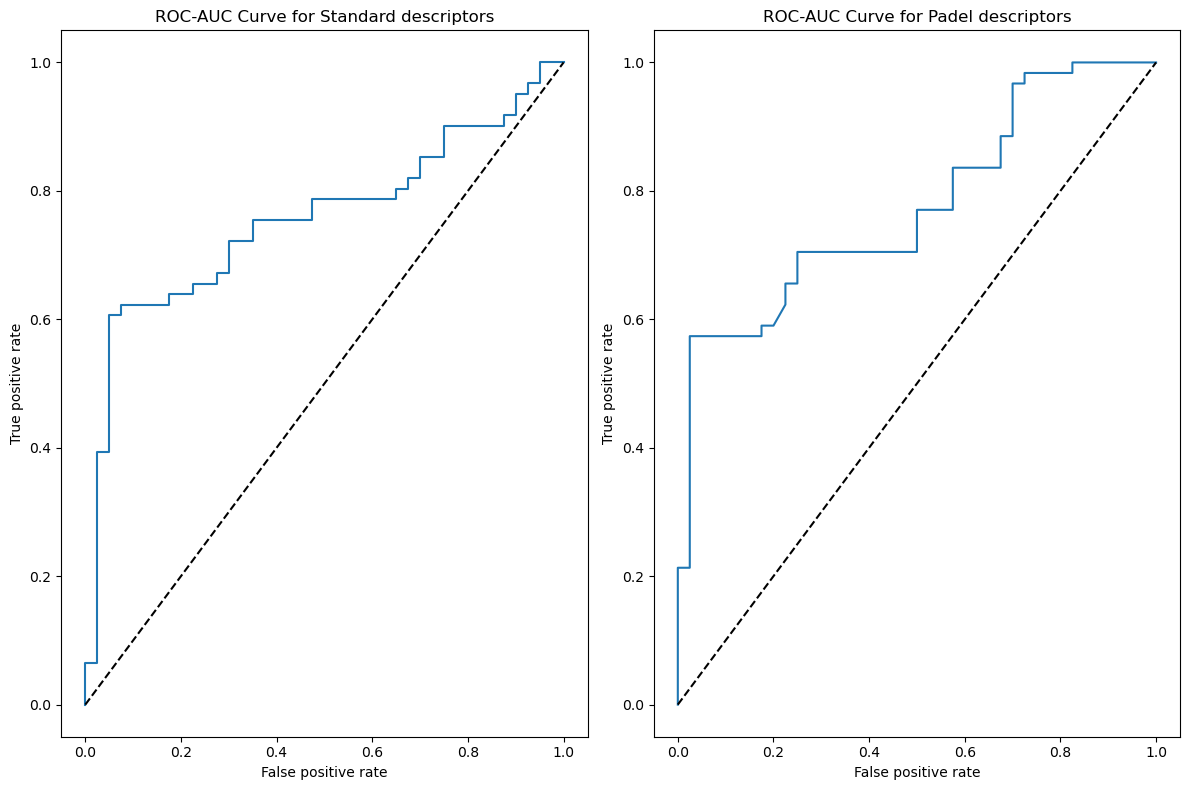

In [29]:
calculate_to_score(LogisticRegression(random_state = 0, max_iter = 1000), estimator_name='Logistic Regression', 
                   param_grid = {'logisticregression__C':hp.loguniform(label = 'C', low = -4*np.log(10), high  = 2*np.log(10))},
                  groups=groups)

100%|██████████| 50/50 [00:08<00:00,  5.84trial/s, best loss: -0.6054254851989602]
{'C': 2.2699309263349297}
100%|██████████| 50/50 [00:08<00:00,  5.65trial/s, best loss: -0.5243309235036909]
{'C': 0.6586906935122736}


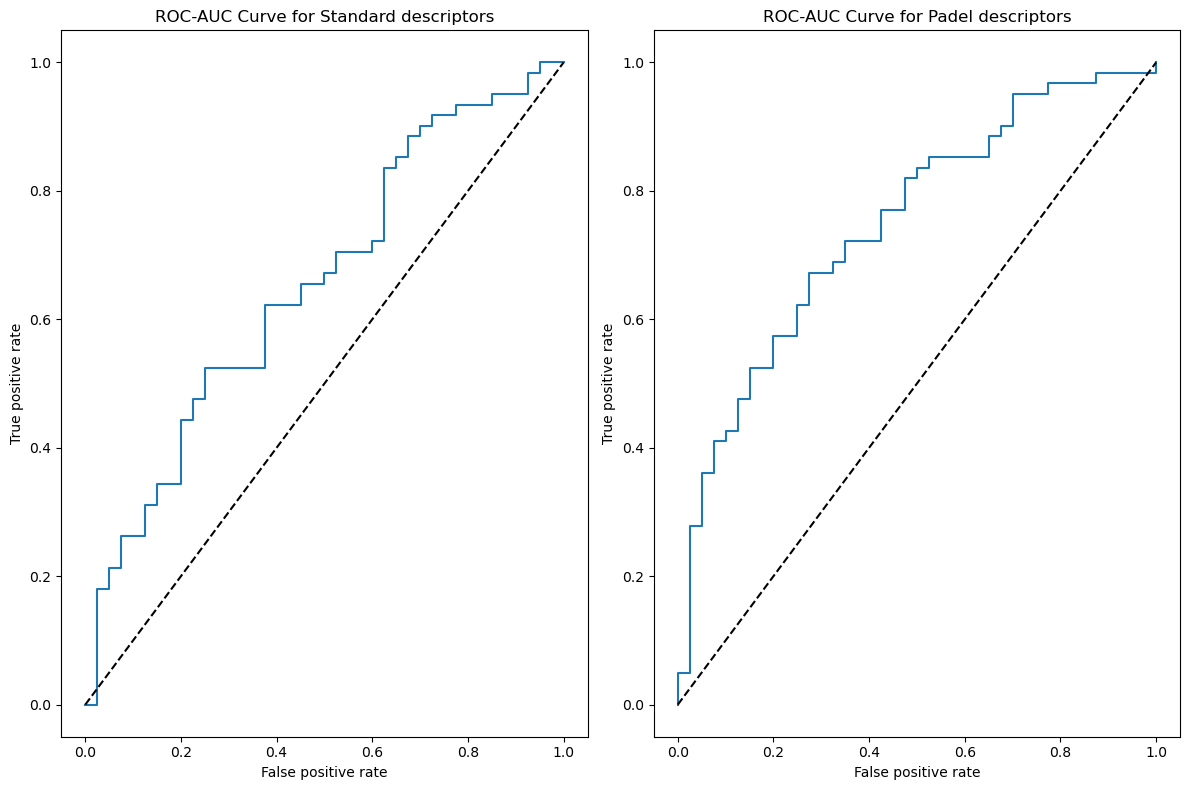

In [31]:
calculate_to_score(LogisticRegression(random_state = 0, max_iter = 1000), estimator_name='Logistic Regression', 
                   param_grid = {'logisticregression__C':hp.loguniform(label = 'C', low = -4*np.log(10), high  = 2*np.log(10))},
                  groups=groups, descriptors_dict = descriptors_dict_pca, type = 'PCA', target = target )

**Random Forest**

In [32]:
space={'randomforestclassifier__max_depth':hp.randint('max_depth',1,50),  'randomforestclassifier__max_features':hp.choice('max_features', [None, 'sqrt', 'log2']),
       'randomforestclassifier__min_samples_split':hp.randint('min_samples_split', 2, 8),
       'randomforestclassifier__min_samples_leaf': hp.randint('min_samples_leaf', 1, 10)}

100%|██████████| 50/50 [01:31<00:00,  1.83s/trial, best loss: -0.7844658486167921]
{'max_depth': 36, 'max_features': 0, 'min_samples_leaf': 4, 'min_samples_split': 6}
100%|██████████| 50/50 [01:23<00:00,  1.67s/trial, best loss: -0.7790026703819807]
{'max_depth': 27, 'max_features': 0, 'min_samples_leaf': 9, 'min_samples_split': 5}


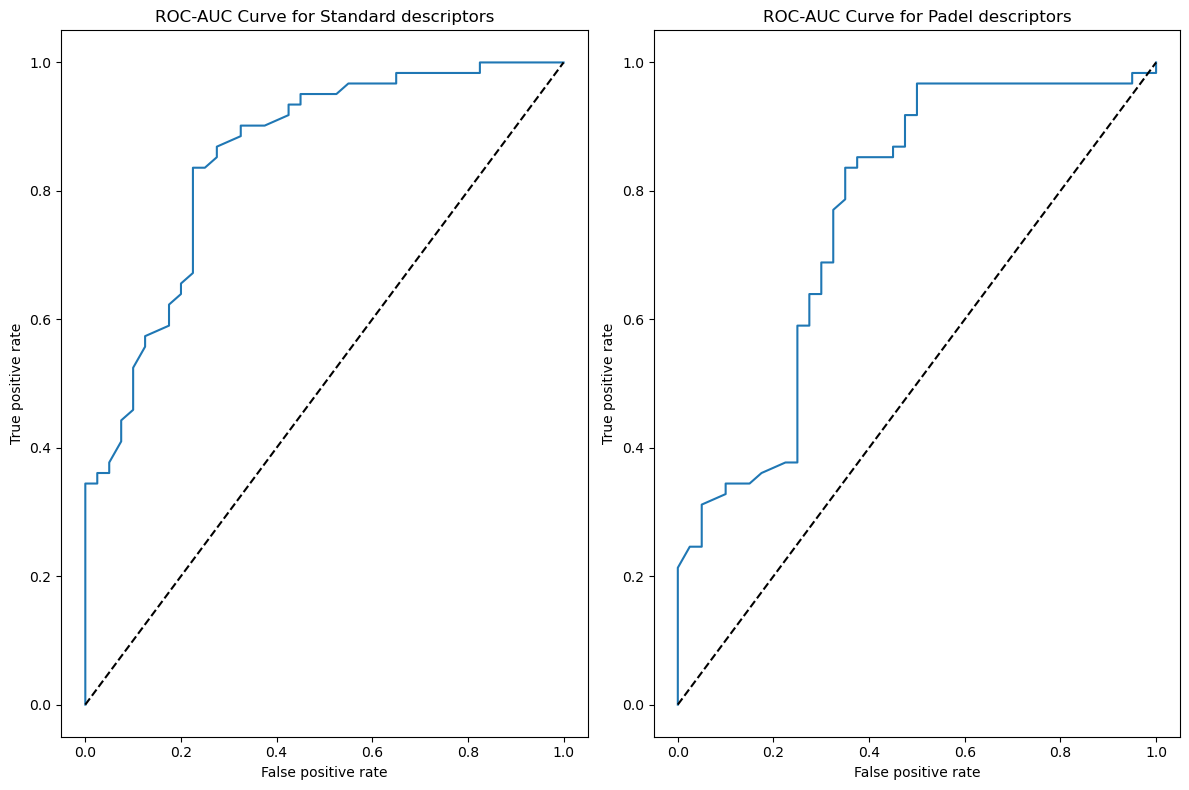

In [33]:
calculate_to_score(RandomForestClassifier(random_state = 0, n_jobs=-1), estimator_name = 'Random Forest', param_grid=space,
                   descriptors_dict=descriptors_dict, groups=groups,
                   target=target,
                   type = 'Full')

100%|██████████| 50/50 [05:24<00:00,  6.49s/trial, best loss: -0.6586822465808164]
{'max_depth': 43, 'max_features': 0, 'min_samples_leaf': 8, 'min_samples_split': 6}
100%|██████████| 50/50 [05:47<00:00,  6.95s/trial, best loss: -0.6225419304884293]
{'max_depth': 35, 'max_features': 0, 'min_samples_leaf': 7, 'min_samples_split': 2}


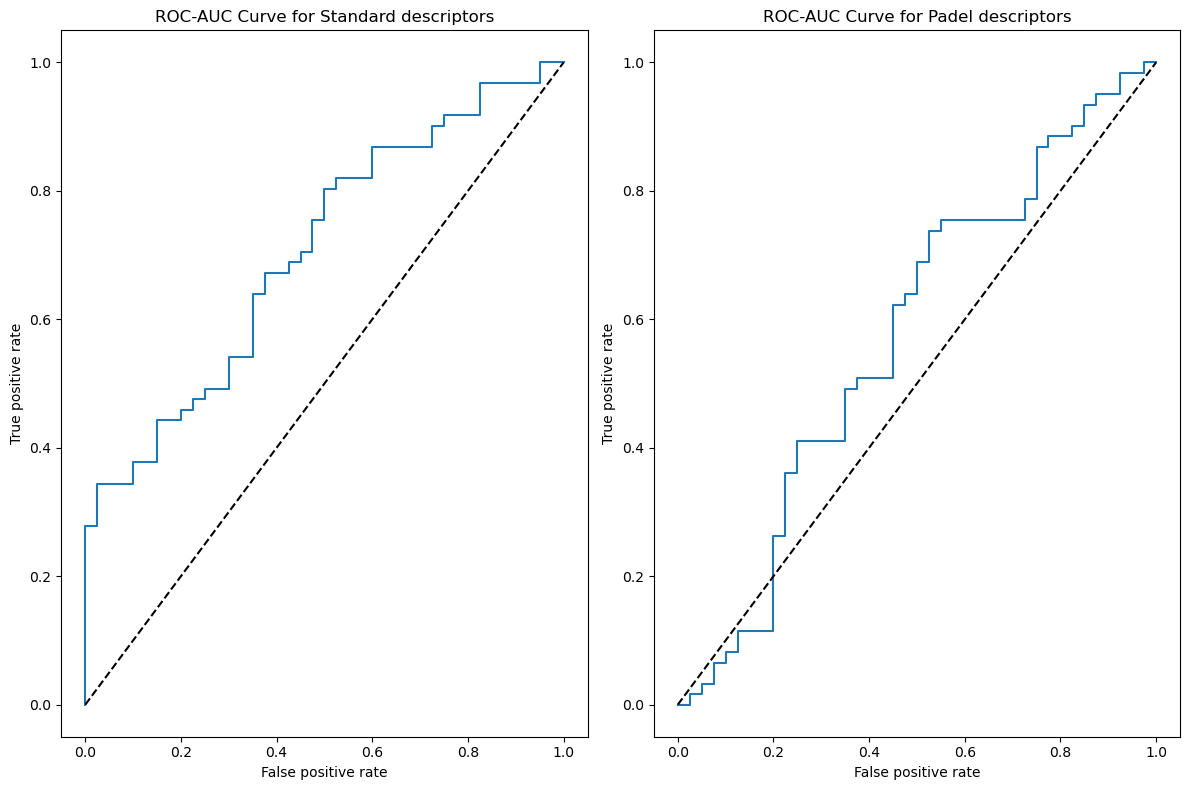

In [34]:
calculate_to_score(RandomForestClassifier(random_state = 0, n_jobs=-1), estimator_name = 'Random Forest', param_grid=space,
                   descriptors_dict=descriptors_dict_pca, groups=groups,
                   target=target,
                   type = 'PCA')

**XGBOOST**

In [35]:
space = {'xgbclassifier__n_estimators':hp.randint('n_estimators', 1, 30),
         'xgbclassifier__learning_rate': hp.loguniform('learning_rate', low = -4*np.log(10), high  = 2*np.log(10)),
         'xgbclassifier__reg_alpha':hp.loguniform(label = 'reg_alpha', low = -4*np.log(10), high  = 2*np.log(10)),
         'xgbclassifier__max_depth':hp.randint('max_depth', 1, 100)}

 72%|███████▏  | 36/50 [01:04<00:21,  1.52s/trial, best loss: -0.7822846003898636]

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



 74%|███████▍  | 37/50 [01:05<00:18,  1.39s/trial, best loss: -0.7822846003898636]

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



 98%|█████████▊| 49/50 [01:28<00:01,  1.93s/trial, best loss: -0.7822846003898636]

...

 32%|███▏      | 16/50 [00:19<00:43,  1.27s/trial, best loss: -0.7812744077708396]

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



 34%|███▍      | 17/50 [00:20<00:36,  1.11s/trial, best loss: -0.7812744077708396]

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



100%|██████████| 50/50 [01:00<00:00,  1.21s/trial, best loss: -0.7973005978213901]
{'learning_rate': 0.0520513496900953, 'max_depth': 47, 'n_estimators': 20, 'reg_alpha': 0.00026054577519499337}


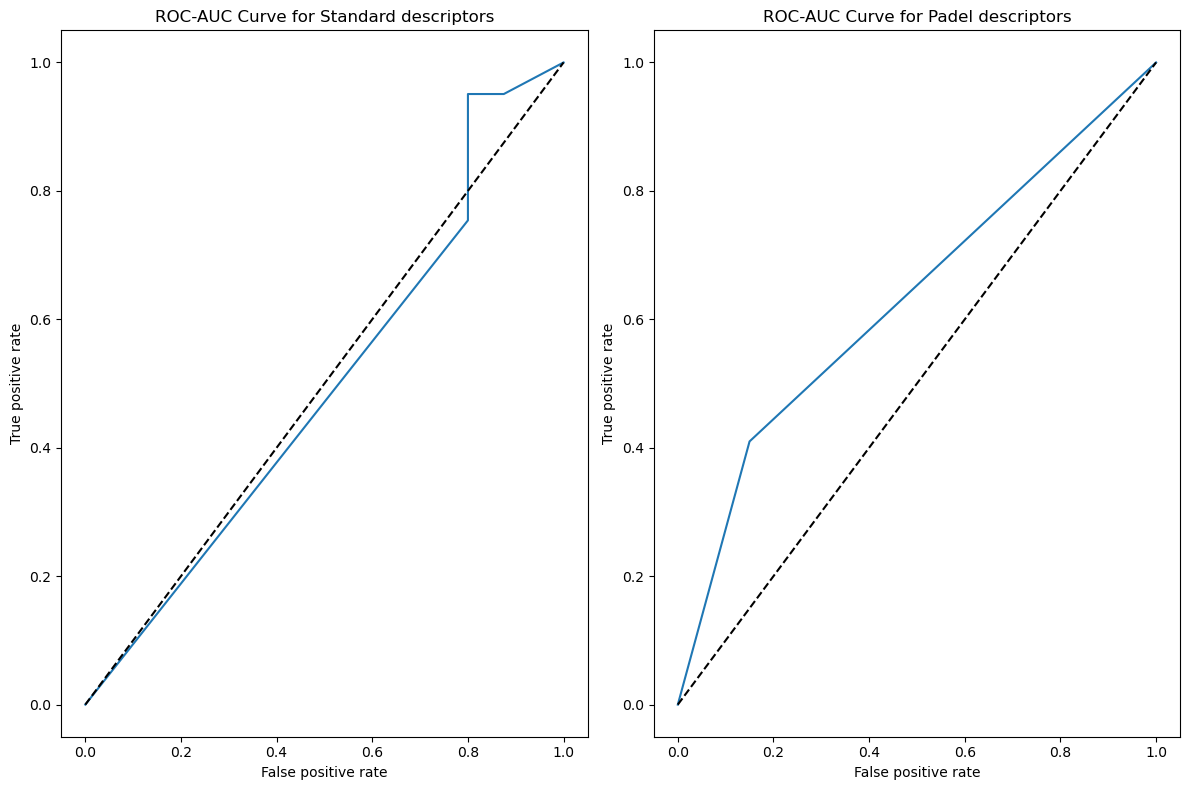

In [36]:
calculate_to_score(XGBClassifier(n_jobs = -1), estimator_name='Gradient boosting', param_grid = space,
                   descriptors_dict=descriptors_dict,
                   target=target,
                   type = 'Full')

 74%|███████▍  | 37/50 [03:49<01:07,  5.17s/trial, best loss: -0.6624889384576005]

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



 80%|████████  | 40/50 [04:04<00:56,  5.66s/trial, best loss: -0.6624889384576005]

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



100%|██████████| 50/50 [04:49<00:00,  5.79s/trial, best loss: -0.6624889384576005]
{'learning_rate': 0.10937206272255104, 'max_depth': 77, 'n_estimators': 11, 'reg_alpha': 0.0037071613424603162}
 16%|█▌        | 8/50 [00:38<04:18,  6.16s/trial, best loss: -0.6126376829612422]

...

 80%|████████  | 40/50 [03:20<00:30,  3.03s/trial, best loss: -0.6749564482990624]

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



 84%|████████▍ | 42/50 [03:23<00:16,  2.09s/trial, best loss: -0.6749564482990624]

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



100%|██████████| 50/50 [03:50<00:00,  4.62s/trial, best loss: -0.6749564482990624]
{'learning_rate': 33.37201339647135, 'max_depth': 28, 'n_estimators': 17, 'reg_alpha': 0.00011031144123474975}


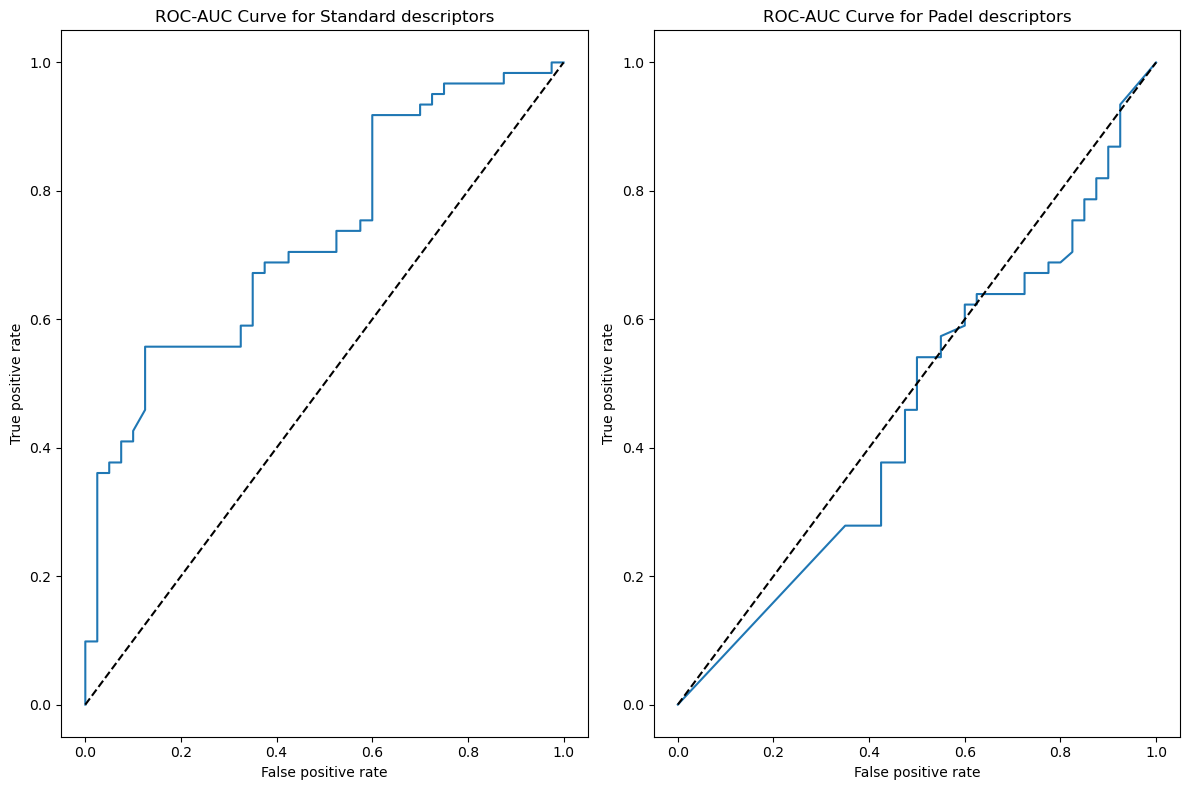

In [37]:
calculate_to_score(XGBClassifier(n_jobs = -1), estimator_name='Gradient boosting', param_grid = space,
                   descriptors_dict=descriptors_dict_pca,
                   target=target,
                   type = 'PCA')

**SVM**

In [38]:
space = {'svc__C':hp.loguniform('C', -3*np.log(10), 2*np.log(10)),
         'svc__kernel':hp.choice('kernel', ['rbf','poly','linear', 'sigmoid']),
         'svc__degree':hp.choice('degree', [2,3, 4]),
         'svc__gamma':hp.choice('gamma', ['scale', 'auto']),
         'svc__coef0':hp.loguniform('coef0', -3*np.log(10), 0*np.log(10))}

100%|██████████| 50/50 [05:19<00:00,  6.39s/trial, best loss: -0.6792769413643633]
{'C': 1.0503296106349453, 'coef0': 0.011947818795192168, 'degree': 1, 'gamma': 0, 'kernel': 1}
100%|██████████| 50/50 [03:27<00:00,  4.14s/trial, best loss: -0.7349659863945578]
{'C': 91.93448756977625, 'coef0': 0.1246441384405837, 'degree': 0, 'gamma': 0, 'kernel': 0}


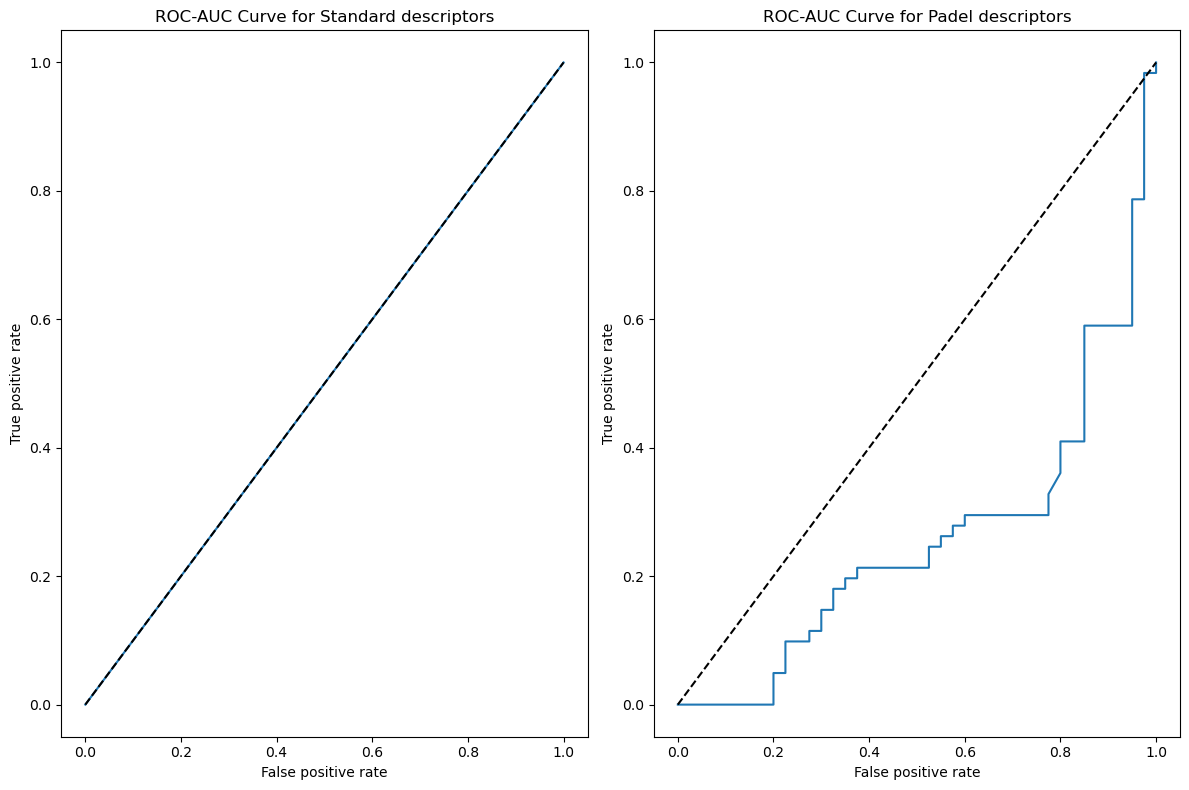

In [39]:
calculate_to_score(SVC(probability=True), estimator_name = 'SVC', param_grid = space, 
                   descriptors_dict=descriptors_dict, target = target, groups=groups, type = 'Full')

100%|██████████| 50/50 [02:03<00:00,  2.48s/trial, best loss: -0.5981332914257544]
{'C': 0.07633379836874635, 'coef0': 0.05782508958530839, 'degree': 0, 'gamma': 0, 'kernel': 1}
100%|██████████| 50/50 [02:07<00:00,  2.55s/trial, best loss: -0.5662612036261161]
{'C': 2.935498851900525, 'coef0': 0.17756400920277837, 'degree': 1, 'gamma': 0, 'kernel': 0}


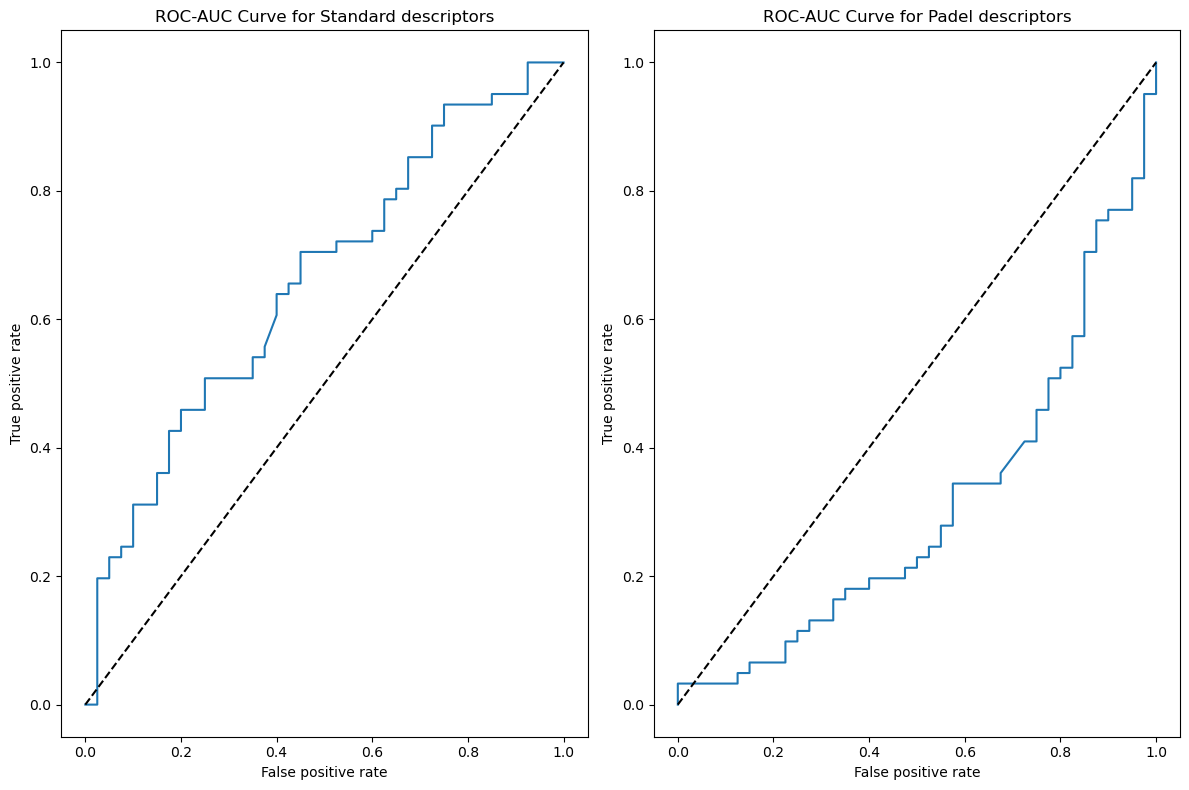

In [40]:
calculate_to_score(SVC(probability=True), estimator_name = 'SVC', param_grid = space, 
                   descriptors_dict=descriptors_dict_pca, target = target, groups=groups, type = 'PCA')

**KNearestNeighbors**

In [41]:
space = {'kneighborsclassifier__n_neighbors':hp.randint('n_neighbors',1, 10),
         'kneighborsclassifier__weights':hp.choice('weights', ['uniform', 'distance']),
         'kneighborsclassifier__metric':hp.choice('metric', ['minkowski', 'chebyshev', 'cosine', 'euclidean'])}


 26%|██▌       | 13/50 [00:06<00:19,  1.88trial/s, best loss: -0.6898673358232182]

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



 52%|█████▏    | 26/50 [00:12<00:12,  1.88trial/s, best loss: -0.7047662141779789]

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



 58%|█████▊    | 29/50 [00:14<00:11,  1.83trial/s, best loss: -0.7047662141779789]

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



100%|██████████| 50/50 [00:25<00:00,  1.97trial/s, best loss: -0.7295238095238096]
{'metric': 1, 'n_neighbors': 1, 'weights': 0}
 16%|█▌        | 8/50 [00:02<00:14,  3.00trial/s, best loss: -0.6935046149607385]

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



100%|██████████| 50/50 [00:17<00:00,  2.80trial/s, best loss: -0.7735087719298246]
{'metric': 1, 'n_neighbors': 5, 'weights': 1}


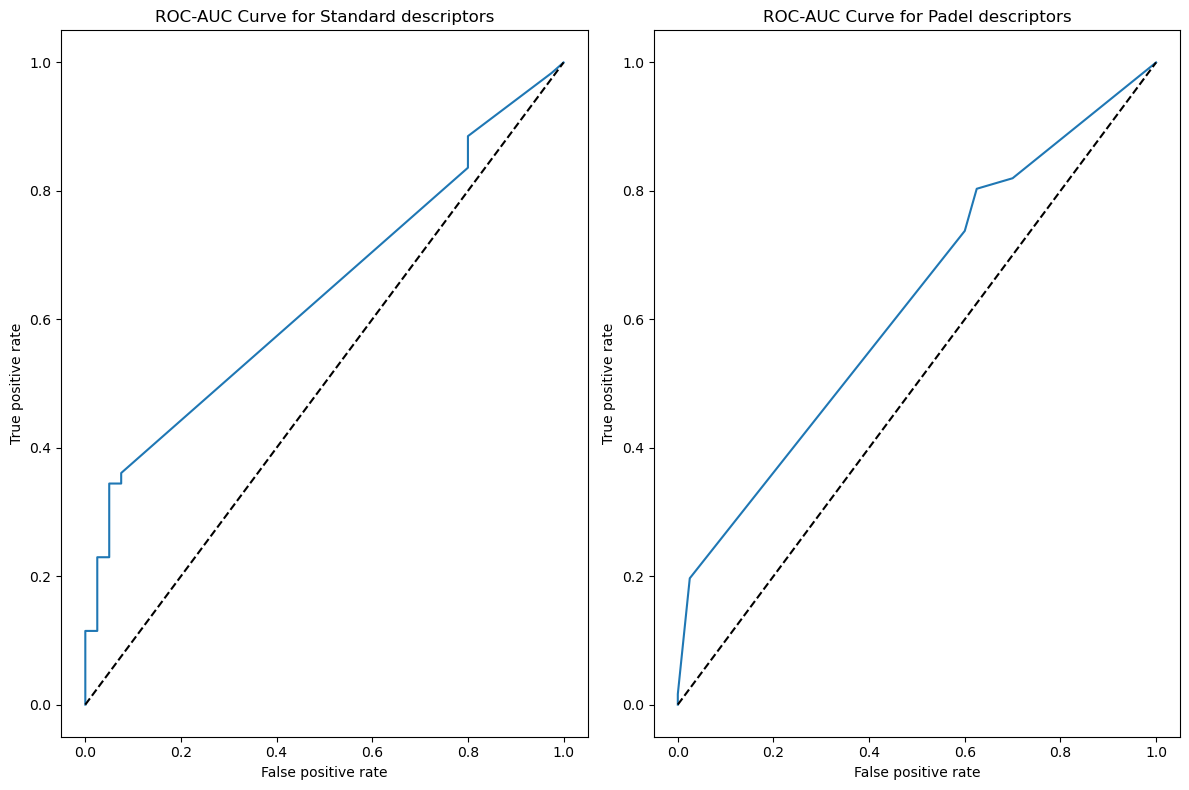

In [42]:
calculate_to_score(KNeighborsClassifier(), estimator_name='KMeans', param_grid=space, 
                   descriptors_dict=descriptors_dict, target=target, groups = groups, type = 'Full')

100%|██████████| 50/50 [00:10<00:00,  4.67trial/s, best loss: -0.5649018672773506]
{'metric': 1, 'n_neighbors': 9, 'weights': 1}
  4%|▍         | 2/50 [00:00<00:12,  3.99trial/s, best loss: -0.46271553008395117]

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



 10%|█         | 5/50 [00:01<00:08,  5.02trial/s, best loss: -0.5110933835651605] 

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(resul

 16%|█▌        | 8/50 [00:01<00:08,  4.77trial/s, best loss: -0.5110933835651605]

...

 98%|█████████▊| 49/50 [00:10<00:00,  4.59trial/s, best loss: -0.5110933835651605]

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



100%|██████████| 50/50 [00:11<00:00,  4.48trial/s, best loss: -0.5110933835651605]

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))




{'metric': 0, 'n_neighbors': 6, 'weights': 1}


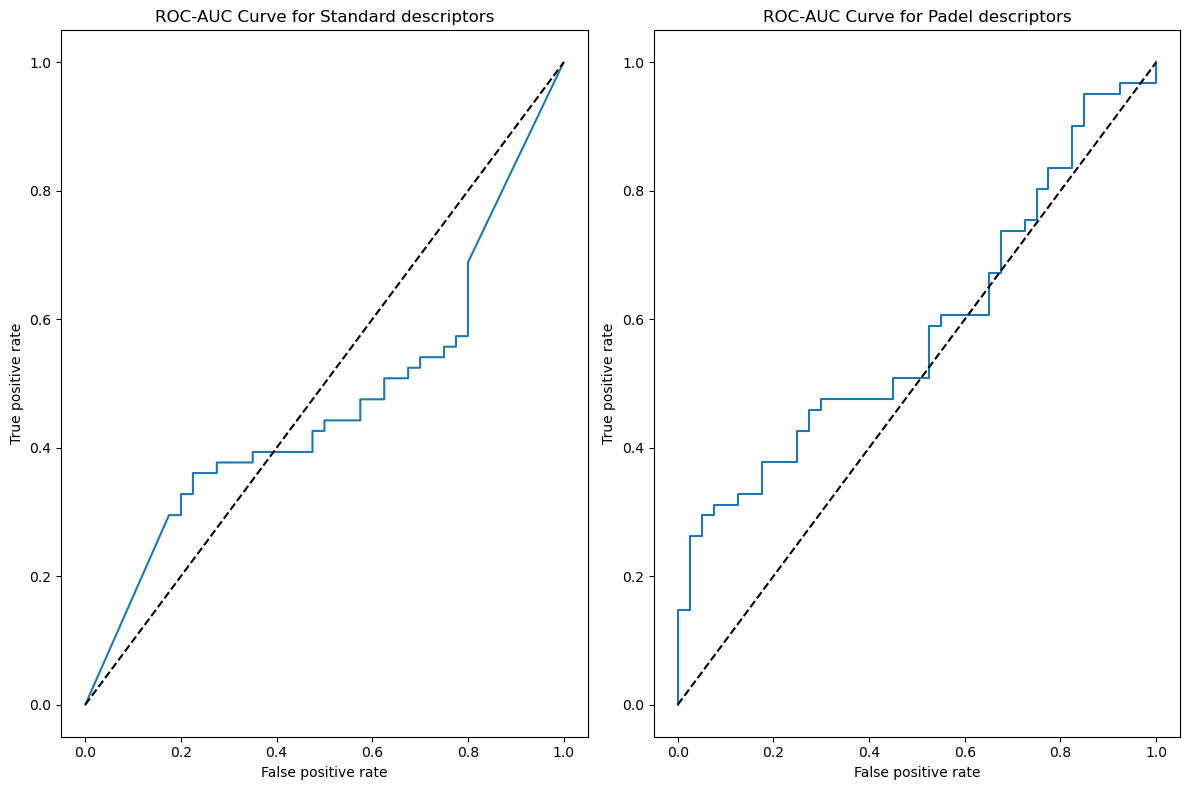

In [43]:
calculate_to_score(KNeighborsClassifier(), estimator_name='KMeans', param_grid=space, 
                   descriptors_dict=descriptors_dict_pca, target=target, groups = groups, type = 'PCA')

Let's save results into pickle file and show the final scores model in readable format

In [27]:
with open('score_groups_hyper_opt.pickle', 'wb') as output:
    pickle.dump(scores, output)

In [44]:
pd.DataFrame(scores)

,Descriptors,Full or PCA,Accuracy,F1 - score,Precision,Recall,ROC-AUC Score,Estimator
0,Standard,Full,0.693069,0.739496,0.758621,0.721311,0.755328,Logistic Regression
1,Padel,Full,0.702970,0.727273,0.816327,0.655738,0.775000,Logistic Regression
2,Standard,PCA,0.623762,0.666667,0.716981,0.622951,0.652459,Logistic Regression
3,Padel,PCA,0.663366,0.763889,0.662651,0.901639,0.747541,Logistic Regression
4,Standard,Full,0.683168,0.680000,0.871795,0.557377,0.852664,Random Forest
5,Padel,Full,0.663366,0.690909,0.775510,0.622951,0.763115,Random Forest
6,Standard,PCA,0.633663,0.694215,0.700000,0.688525,0.704508,Random Forest
7,Padel,PCA,0.485149,0.409091,0.666667,0.295082,0.572951,Random Forest
8,Standard,Full,0.534653,0.661871,0.589744,0.754098,0.494877,Gradient boosting
9,Padel,Full,0.584158,0.543478,0.806452,0.409836,0.629918,Gradient boosting


However, as opposed to the case were splitting was random and did not take the chemical nature of the additive into account, the same models have better performace and the best model in this case was Random Forest, again, with Standard Descriptors. The best parameters were:  
**{'max_depth': 36, 'max_features': 0, 'min_samples_leaf': 4, 'min_samples_split': 6}**